In [1]:
import os
from typing import Sequence,TypedDict, Annotated , Literal
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage,ToolMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END,START
from langgraph.prebuilt import create_react_agent
# from langchain.agents import initialize_agent
from sentence_transformers import SentenceTransformer
from langgraph.prebuilt import ToolNode
import requests
from bs4 import BeautifulSoup

In [2]:
from dotenv import load_dotenv
load_dotenv()
# memory = ConversationBufferMemory(return_messages=True)

True

In [3]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")

In [ ]:
# from langgraph.graph import StateGraph,END,MessagesState

In [4]:
# CHUNKING VEC DB1
url = "https://docs.snowflake.com/en/user-guide/query-acceleration-service"
res = requests.get(url)
soup = BeautifulSoup(res.text, "html.parser")
text = soup.get_text()

# soup
header_tags = ['h1', 'h2', 'h3', 'h4', 'h5', 'h6']
db1 = {}
current_header = None

for i,tag in enumerate(soup.find_all(['h1', 'h2', 'h3', 'h4', 'h5', 'h6','p','div'])):  
    if tag.name.startswith('h'):
    
        current_header = tag.text.replace('¶', '')
        db1[current_header] = []
    elif current_header:
        text = tag.text.replace('¶', '')
        if text: 
            db1[current_header].append(text.replace('¶', ''))


chunks_db1=[]
for section_title, paragraphs in db1.items():
  chunks_db1.append({
            "Topic": section_title,
            "Context": ','.join(paragraphs)
        })
  
len(chunks_db1)

23

In [5]:
chunks_db1[0]

{'Topic': 'Using the Query Acceleration Service (QAS)',
 'Context': ' Enterprise Edition Feature,This feature requires Enterprise Edition (or higher). To inquire about upgrading, please contact Snowflake Support.,The query acceleration service (QAS) can accelerate parts of the query workload in a warehouse. When it is enabled for a warehouse,\nit can improve overall warehouse performance by reducing the impact of outlier queries, which are queries that use more resources than the\ntypical query. The query acceleration service does this by offloading portions of the query processing work to shared compute resources that\nare provided by the service.,Examples of the types of workloads that might benefit from the query acceleration service include:,Ad hoc analytics.,Workloads with unpredictable data volume per query.,Queries with large scans and selective filters.,The query acceleration service can handle these types of workloads more efficiently by performing more work in parallel and re

In [6]:
# CHUNKING VEC DB 2

url = "https://docs.snowflake.com/en/user-guide/tasks-graphs"
res = requests.get(url)
soup = BeautifulSoup(res.text, "html.parser")
text = soup.get_text()

# soup
header_tags = ['h1', 'h2', 'h3', 'h4', 'h5', 'h6']
db2 = {}
current_header = None

for i,tag in enumerate(soup.find_all(['h1', 'h2', 'h3', 'h4', 'h5', 'h6','p','div'])):  
    if tag.name.startswith('h'):
    
        current_header = tag.text.replace('¶', '')
        db2[current_header] = []
    elif current_header:
        text = tag.text.replace('¶', '')
        if text: 
            db2[current_header].append(text.replace('¶', ''))


chunks_db2=[]
for section_title, paragraphs in db2.items():
  chunks_db2.append({
            "Topic": section_title,
            "Context": ','.join(paragraphs)
        })
  
len(chunks_db2)

28

In [7]:
# CHUNKING VEC DB 3
url = "https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-agents"
res = requests.get(url)
soup = BeautifulSoup(res.text, "html.parser")
text = soup.get_text()

html_dict={}
# soup
header_tags = ['h1', 'h2', 'h3', 'h4', 'h5', 'h6']
html_dict = {}
current_header = None

for i,tag in enumerate(soup.find_all(['h1', 'h2', 'h3', 'h4', 'h5', 'h6','p','div'])):  
    if tag.name.startswith('h'):
    
        current_header = tag.text.replace('¶', '')
        html_dict[current_header] = []
    elif current_header:
        text = tag.text.replace('¶', '')
        if text: 
            html_dict[current_header].append(text.replace('¶', ''))


chunks_db3=[]
for section_title, paragraphs in html_dict.items():
  chunks_db3.append({
            "Topic": section_title,
            "Context": ' '.join(paragraphs)
        })
  
len(chunks_db3)

10

In [8]:
from langchain.chat_models import init_chat_model
# llm=init_chat_model("groq:llama-3.1-8b-instant")
# llm
llm=ChatGroq(model_name="Gemma2-9b-It")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000021B1EC72F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021B1ECA7FB0>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
import chromadb
client = chromadb.Client()
model = SentenceTransformer ('BAAI/bge-large-en-v1.5')
# from langchain_huggingface import HuggingFaceEmbeddings
# model=HuggingFaceEmbeddings(model_name="BAAI/bge-large-en-v1.5")

embeddings_db1=model.encode(chunks_db1, batch_size=3 ,show_progress_bar=True,normalize_embeddings=True).tolist()
embeddings_db2=model.encode(chunks_db2, batch_size=3 ,show_progress_bar=True,normalize_embeddings=True).tolist()
embeddings_db3=model.encode(chunks_db3, batch_size=3 ,show_progress_bar=True,normalize_embeddings=True).tolist()

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
# COLLECTION FOR DB1 USING CHROMA DB 
    
collections_db1 = client.get_or_create_collection(name="snowflake_qas")
collections_db1.add(
documents=[item["Context"] for item in chunks_db1],
embeddings=embeddings_db1,
ids=[item["Topic"] for item in chunks_db1] )

# COLLECTION FOR DB2 USING CHROMA DB 
    
collections_db2 = client.get_or_create_collection(name="snowflake_task_graphs")
collections_db2.add(
documents=[item["Context"] for item in chunks_db2],
embeddings=embeddings_db2,
ids=[item["Topic"] for item in chunks_db2]
)

# COLLECTION FOR DB3 USING CHROMA DB 
        
collections_db3 = client.get_or_create_collection(name="snowflake_cortex_agent")
collections_db3.add(
documents=[item["Context"] for item in chunks_db3],
embeddings=embeddings_db3,
ids=[item["Topic"] for item in chunks_db3]
)

In [13]:
@tool
def vec_snowflake_qas(qry:str)->str:
    """
    Retrieves context related to the Snowflake Query Acceleration Service (QAS).

    This tool generates an embedding of the user's query and performs a similarity search 
    against a vector store containing information about QAS functionality, usage, and concepts 
    in Snowflake. It returns the most relevant document chunks.

    Args:
        qry: The user's query about the Snowflake Query Acceleration Service.

    Returns:
        A string containing the top relevant context chunks related to Snowflake Query Acceleration Service (QAS).
    """
    query_embedding = model.encode([qry]).tolist()
    results = collections_db1.query(
    query_embeddings=query_embedding,
    n_results=3  # Top 3 similar vectors
    )
    docs=results['documents'][0]
    res_docs= ','.join([docs[i] for i in range(len(docs))])
    
    return res_docs

@tool
def vec_snowflake_tasks(qry:str)->str:
    """
    Retrieves context related to Snowflake Tasks , Snowflake Finalizer Tasks   functionality and all information about Task Graphs.

    This tool generates an embedding of the user's query and searches a vector store containing 
    documentation and information on Snowflake task functionality, scheduling, and workflows. 
    It returns the most relevant document chunks.

    Args:
        qry: The user's query about Snowflake Tasks.

    Returns:
        A string containing the top relevant context chunks related to Snowflake Tasks.
    """
    query_embedding = model.encode([qry]).tolist()
    results = collections_db2.query(
    query_embeddings=query_embedding,
    n_results=3  # Top 3 similar vectors
    )
    docs=results['documents'][0]
    res_docs= ','.join([docs[i] for i in range(len(docs))])
    return res_docs

@tool
def vec_snowflake_cortex_agent(qry:str)->str:
    """
    Retrieves context related to Snowflake Cortex Agents.

    This tool encodes the user’s query and searches a vector store containing embeddings 
    of Snowflake Cortex Agent documentation and capabilities. It returns the most relevant 
    document chunks.

    Args:
        qry: The user's query about Cortex Agents in Snowflake.

    Returns:
        A string containing the top relevant context chunks related to snowflake Cortex Agents.
    """

    query_embedding = model.encode([qry]).tolist()
    results = collections_db3.query(
    query_embeddings=query_embedding,
    n_results=3  # Top 3 similar vectors
    )
    docs=results['documents'][0]
    res_docs= ','.join([docs[i] for i in range(len(docs))])
    return res_docs



In [14]:
#Define the state
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]
    

In [ ]:
# import json
# def router_agent(state: AgentState):
#     """ROUTER AGENT TO FETCH THE RELEVANT CHUNKS"""
#     try:
#         # qry=messages=state['messages'][-1].content
#         messages=state['messages']#.content
#         # qry = ''.join([msg.content for msg in state['messages']])
#         system_msg = SystemMessage(
#             content="You are an expert retriver assistant. \
#                 You assist the user by providing relevant chunks based on the user query \
#                 Based on the user query and conversation, decide which tool should be used for extracting chunks.\
#                 Choose the correct tool from the provided list of tools to retrieve the relevant chunks for the user query. \
#                 If no relevant tools found for the user query return No data found for the current query ."
#                         )
#         #bind llm with all tools
#         llm_search_tool=llm.bind_tools([vec_snowflake_qas,vec_snowflake_tasks,vec_snowflake_cortex_agent])
#         response=llm_search_tool.invoke([system_msg]+[messages])
#         tools=[vec_snowflake_qas,vec_snowflake_tasks,vec_snowflake_cortex_agent]
        
        

#         if response.additional_kwargs.get("tool_calls",[]):
#             tool_calls=response.additional_kwargs.get("tool_calls",[])
#             tool_name=tool_calls[0]["function"]["name"]
#             tool_args = json.loads(tool_calls[0]["function"]["arguments"])

#             tool=next((t for t in tools if t.name==tool_name),None)
#             if tool:
#                 res=tool.run(tool_args)
#                 return  {
#                 "messages": [messages,res],
#                 "next_agent": "generator" 
#                 }  

#         else:
            
#             tool=next((t for t in tools if t.name in response.content),None)
#             if tool:
#                 args={'qry': messages}
#                 res=tool.run(args)
#                 return  {
#                 "messages": [messages,res],
#                 "next_agent": "generator" }  
#             else:
#                 resp=f'No relevant data found.Please adjust your query for snowflake topics QUERY ACCELARATION , SNOWFLAKE TASKS , CORTEX AGENTS'
#                 return  {
#                 "messages": [resp],
#                 "next_agent": "generator" }
               
#     except json.JSONDecodeError:
#         resp="Error: Failed to parse tool arguments (invalid JSON)."
#         return  {
#                 "messages": [resp],
#                 "next_agent": "__end__" 
#                 }

#     except ValueError as ve:
#         resp=f"ValueError:, {ve}"
#         return  {
#                 "messages": [resp],
#                 "next_agent": "__end__" 
#                 }

#     except Exception as e:
#         resp=f"Unexpected Error: {type(e).__name__} -{e}"
#         return  {
#                 "messages": [resp],
#                 "next_agent": "__end__" 
#                 }


In [ ]:
# x=retriver_agent({"messages":"what is query accelaration service"})
# # x=retriver_agent({"messages":"What is snowflake"})
# x

In [15]:
from langchain_core.prompts import PromptTemplate
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
def similar_score(qry,embeddings,model):
    qry_embed= model.encode([qry])
    embedding_array = np.array(embeddings)
    similarities = cosine_similarity(qry_embed, embedding_array)[0]
    if max(similarities) > 0.65:
        return "YES"
    else:
        return "NO"

In [16]:
from langchain_core.pydantic_v1 import BaseModel,Field
# from langgraph.prebuilt import tools_condition
class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'YES' or 'NO'")

c:\Users\Bhakti Thakur\agenticai\agentvenv\Lib\site-packages\IPython\core\interactiveshell.py:3699: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [17]:

def router_agent(state: AgentState):
    print("--- CHECKING IN DATABASE FOR RELEVANT INFO FOR THE QUERY ---")
    print("I AM IN ROUTER AGENT")
    #IF MESSAGE IS RELEVANT TO TOOLS DEFINED , THEN PASS TO GENERATE , ELSE END CONV
    TOOLS=[vec_snowflake_cortex_agent,vec_snowflake_tasks,vec_snowflake_qas]
    tools_dict={'vec_snowflake_qas':[vec_snowflake_qas,embeddings_db1],
    'vec_snowflake_tasks':[vec_snowflake_tasks,embeddings_db2],
    'vec_snowflake_cortex_agent':[vec_snowflake_cortex_agent,embeddings_db3]
}

    llm_with_structure_op=llm.with_structured_output(grade)
    
    
    resp=[]
    messages=state['messages'][0].content
    for val in tools_dict.keys():
        doc=tools_dict[val][0]
        scores=similar_score(messages,tools_dict[val][1],model)
        if scores =='YES':
            resp.append([scores,val])
            
    if len(resp)!=0:
        print("---DECISION: RELEVANT DETAILS FOUND FOR THE QUERY---")
        print("---Here the RAG answer----")
        llm_with_tool = llm.bind_tools(TOOLS)
        response = llm_with_tool.invoke(messages)
        #response=handle_query(messages)
        return {"messages": [response] 
                }
        
    else:
        print("---DECISION: NO RELEVANT DETAILS FOUND FOR THE QUERY---")
        print("---Here is a AI generated message for the question")
        # llm_with_tool = llm.bind_tools(TOOLS)
        
        # # return response
        
        # msg= f'No relevant details found for user question {messages} . Please refine the prompt or question to fetch details from followinf Snowflake Topics :  \
        #       Snowflake Query Accelaration \n Snowflake Tasks \n Snowflake Cortex Agents. Thanks !'
        
        # return {'messages': [AIMessage(content=msg)]} 
        response = llm.invoke(messages)
        # f'No relevant details found for user question {messages} . Please refine the prompt or question to fetch details from followinf Snowflake Topics :  \
        #        Snowflake Query Accelaration \n Snowflake Tasks \n Snowflake Cortex Agents. Thanks !'
        # llm.invoke(messages)
        return {'messages': [response]} 
    


In [18]:
x=router_agent({"messages":[HumanMessage(content="what are snowflake tasks")]})
x['messages'][-1].content
#This router agent takes details in form of humanmessage

--- CHECKING IN DATABASE FOR RELEVANT INFO FOR THE QUERY ---
I AM IN ROUTER AGENT
---DECISION: RELEVANT DETAILS FOUND FOR THE QUERY---
---Here the RAG answer----


''

In [28]:
def tools_condition_new(state:AgentState):
    message = state["messages"]
    if message[0].additional_kwargs.get("tool_calls",[]):
        return 'retriever'
        
    else:
        return END


In [ ]:
# {'messages': [AIMessage(content='No relevant details found for user question what are tigers . Please refine the prompt or question to fetch details from followinf Snowflake Topics :                Snowflake Query Accelaration \n Snowflake Tasks \n Snowflake Cortex Agents. Thanks !', additional_kwargs={}, response_metadata={})]}

In [29]:
x=router_agent({"messages":[HumanMessage(content="what is a tiger")]})
# st=tools_condition_new({'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9whw2a4am', 'function': {'arguments': '{"qry":"what are tasks"}', 'name': 'vec_snowflake_tasks'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 1441, 'total_tokens': 1528, 'completion_time': 0.158181818, 'prompt_time': 0.027382162, 'queue_time': 0.253727972, 'total_time': 0.18556398}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d1cdb801-4161-4ea5-a3f2-2da4f4ff40a6-0', tool_calls=[{'name': 'vec_snowflake_tasks', 'args': {'qry': 'what are tasks'}, 'id': '9whw2a4am', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1441, 'output_tokens': 87, 'total_tokens': 1528})]})
st=tools_condition_new(x)
st

--- CHECKING IN DATABASE FOR RELEVANT INFO FOR THE QUERY ---
I AM IN ROUTER AGENT
---DECISION: NO RELEVANT DETAILS FOUND FOR THE QUERY---
---Here is a AI generated message for the question


'__end__'

In [30]:
def verification_agent(state: AgentState) ->Literal["Vector_Retriever", "generator"]:
    """VERIFICATION AGENT TO CHECK IF CHUNKS RETRIEVED ARE RELEVANT OR NOT"""
    print('--- VERIFING THE CUNKS----')

    messages=state['messages']
    # max_count=5

          
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content

    llm_with_structure_op=llm.with_structured_output(grade)
    prompt=PromptTemplate(
            template= """ You are an expert comparising agent that takes a user query and compares it with document chunks 
                        Decide and tell if the chunks have the correct information to answer the user's query
                        Here is user query: {messages}
                        Here is the chunk : {details}
                        
                        """,
                        input_variables=["messages", "details"]
        
        )
    chain=prompt | llm_with_structure_op
    response=chain.invoke({"messages": question, "details": docs})
    scores = response.binary_score
    
    if scores == 'YES':
        print('---- ROUTING TO GENERATING FOR O/P --------')
        msg ='generator'
        return {'messages':[msg]}
    elif scores == "NO":
        print('---- CHUNKS NOT RELEVANT---')
        print('---- RE-ROUTING TO FETCH RELEVANT CHUNKS---')
        msg='verifier'
        return {'messages':[msg]}
        
    

In [31]:
def routing_condition(state:AgentState):
    message = state["messages"][-1].content.lower()
    print(f'routing_condition : {message}')
    if message == 'generator':
        return 'generator'
        
    else:
        return 'verifier'

In [32]:
x=routing_condition({'messages':[HumanMessage(content='what are tigers', additional_kwargs={}, response_metadata={}, id='3e877d62-c202-47f5-ab4d-3d6fa96bdea4'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h4amx9xyd', 'function': {'arguments': '{"qry":"How to unlink parent and child task in Snowflake"}', 'name': 'vec_snowflake_tasks'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 1448, 'total_tokens': 1542, 'completion_time': 0.170909091, 'prompt_time': 0.027456821, 'queue_time': 0.25448900199999996, 'total_time': 0.198365912}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b6a18397-525a-422c-beeb-28ab1cf27deb-0', tool_calls=[{'name': 'vec_snowflake_tasks', 'args': {'qry': 'How to unlink parent and child task in Snowflake'}, 'id': 'h4amx9xyd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1448, 'output_tokens': 94, 'total_tokens': 1542}), ToolMessage(content='Dependencies between tasks in a task graph can be severed as a result of the following actions:,ALTER TASK … REMOVE AFTER and ALTER TASK … UNSET FINALIZE remove the link between the target task and the specified\nparent tasks or finalized root task.,DROP TASK and GRANT OWNERSHIP sever all the target task’s links. For example, root task A has child task B, and task B has child task C. If you drop task B, the link between task A and B is severed and so is the link between task B and C.,If any combination of the above actions severs the relationship between the child task and all parent tasks, the\nchild task becomes either a standalone task or a root task.,\nNote\nIf you grant the ownership of a task to its current owner, dependency links might not be severed.\n,Note,If you grant the ownership of a task to its current owner, dependency links might not be severed.,To skip a child task in a task graph, suspend the child task\nusing ALTER TASK … SUSPEND.,When you suspend a child task, the task graph continues to run as though\nthe child task had succeeded. A child task with multiple predecessors\nruns as long as at least one of the predecessors is in a\nresumed state, and all resumed predecessors run successfully to completion.,All tasks in a task graph must have the same task owner and be stored in the same database and schema.,You can transfer ownership of all tasks in a task graph using one of the following actions:,Drop the owner of all tasks in the task graph using DROP ROLE. Snowflake transfers ownership to the\nrole that runs the DROP ROLE command.,Transfer ownership of all tasks in the task graph using GRANT OWNERSHIP on all tasks in a schema.,When you transfer ownership of the tasks in a task graph using these methods, the tasks in the task graph retain their relationships to\neach other.,Transferring ownership of a single task removes the dependency between the task and any parent and child tasks. For more information, see\nUnlink parent and child tasks (in this topic).,\nNote\nDatabase replication does not work for task graphs if the graph is owned by a different role than the role that performs replication.\n,Note,Database replication does not work for task graphs if the graph is owned by a different role than the role that performs replication.', name='vec_snowflake_tasks', id='e5a41146-38ad-4ae5-b8b8-a186e1ea30d5', tool_call_id='h4amx9xyd'), HumanMessage(content='generator', additional_kwargs={}, response_metadata={}, id='281993f5-1444-4a01-ba13-f44a6d5b5af0')]})
x

routing_condition : generator


'generator'

In [33]:
def generator_agent(state: AgentState):
    """GENERATOR AGENT TO PROVIDE RELEVANT ANSWER BY USING THE CHUNKS"""
    messages = state["messages"]
    print('I AM IN GENERATOR AGENT')
    
    question = messages[0].content
    last_message = messages[-2]
    docs = last_message.content
    # return question,last_message,docs

    system_msg = SystemMessage (content= f"""
    You are an Expert Snowflake Architect with 5 years of experience 
    You can answer a user's questions in all aspects of Snowflake Query accleration service , Snowflake Tasks and Cortex Agents. 
    Please answer the following query
    Question:
    {question}
    by leveraging  the context provided below
    Context:
    {docs}
    Provide answer by only using the above context. If the context does not contain information to answer the question, reply: "No data available.""

    
    Instructions to be followed:
    -- Generate the answer in a very detailed and concise way covering all the aspects of the query
    -- Generate answer only relevant to the query asked
    -- Do not add any irrelevant data in the answer 
    -- Anwer should be detailed and in only 10-20 lines strictly. 

    Answer in following format :
    1.Question:{question}
    Generated Answer:
    --> Answer here

                                             
                                        
    """)
   #invoke LLM

    result = llm.invoke([system_msg]+[question])
    return  {
        "messages":[result]
    }


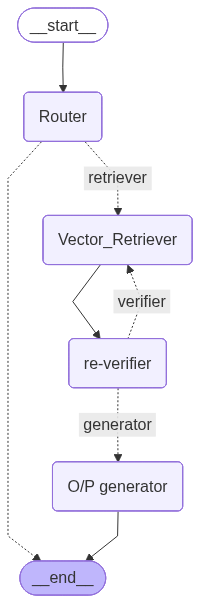

In [34]:
#Build Graph
# from langgraph.prebuilt import tools_condition
workflow=StateGraph(AgentState)
# Add nodes
workflow.add_node("Router", router_agent) 
retrieve=ToolNode([vec_snowflake_qas,vec_snowflake_cortex_agent,vec_snowflake_tasks])
workflow.add_node("Vector_Retriever", retrieve)
workflow.add_node("re-verifier", verification_agent)
workflow.add_node("O/P generator", generator_agent)

# workflow.set_entry_point("Vector_Retriever")
# workflow.add_edge(START,"Router")
workflow.set_entry_point("Router")
workflow.add_edge("Router","Vector_Retriever")
workflow.add_conditional_edges("Router",
                               tools_condition_new,
                               {"retriever": "Vector_Retriever",
                                "__end__" : "__end__",
                                })
workflow.add_edge("Vector_Retriever", "re-verifier")
workflow.add_conditional_edges("re-verifier", 
                               routing_condition, 
                               {"verifier": "Vector_Retriever",
                                "generator":"O/P generator",
                                })

# workflow.add_edge("verifier", "O/P generator")
workflow.add_edge("O/P generator", END)
final_workflow=workflow.compile()

final_workflow
#ROUTER(checks query context)yes -> MAIN AGENT --> ROUTE TO VECTOR RETRIEVER(fetch chunks) -> send to main agent --> if relevant  --> generator --> end
#                                                                                                               -> if no relevant --> back to retriever --> fetch chunks --> send to main agent -> check if relevant --> yes--> generator --> end


In [35]:
# response=final_workflow.invoke({"messages":[HumanMessage(content="How to unlink parent and child task in Snowflake")]})
response=final_workflow.invoke({"messages":"How to unlink parent and child task in Snowflake"})
response=response['messages'][-1].content
print(response)

--- CHECKING IN DATABASE FOR RELEVANT INFO FOR THE QUERY ---
I AM IN ROUTER AGENT
---DECISION: RELEVANT DETAILS FOUND FOR THE QUERY---
---Here the RAG answer----
--- VERIFING THE CUNKS----
---- ROUTING TO GENERATING FOR O/P --------
routing_condition : generator
I AM IN GENERATOR AGENT
1. Question: How to unlink parent and child task in Snowflake
Generated Answer:
--> To unlink a parent-child relationship in a Snowflake task graph, you can use the following methods:

1. **`ALTER TASK ... REMOVE AFTER`**: This command removes the dependency link between a target task and a specified parent task.

2. **`ALTER TASK ... UNSET FINALIZE`**: This command removes the dependency link between a target task and its finalized root task.

3. **`DROP TASK`**: Dropping a child task severs its links to both parent tasks and any child tasks it might have.

4. **`GRANT OWNERSHIP`**: Granting ownership of a task to a different role will sever the dependency links between the task and any parent and child